# Training curves

Reads `metrics.jsonl` from a training run (no dependency on the training code path—only files on disk).

After training with e.g. `python scripts/train.py --output-dir runs/exp1`, set `OUTPUT_DIR` below.

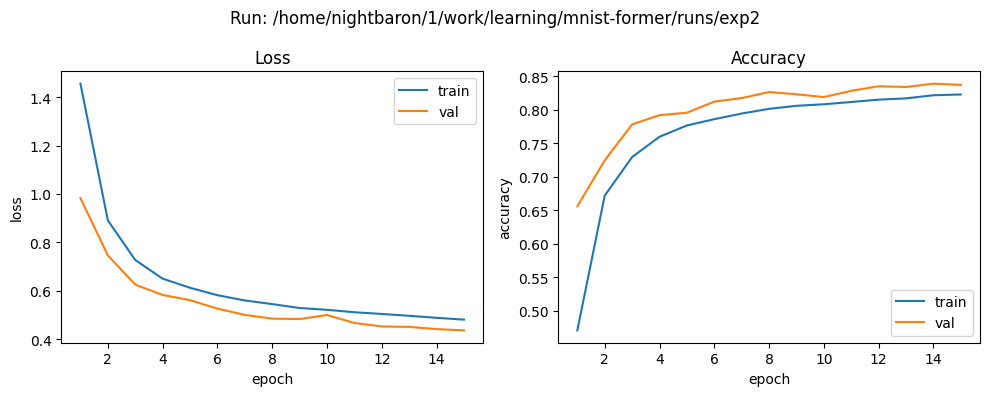

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt

# Change this to your run directory (must contain metrics.jsonl)
OUTPUT_DIR = Path("../runs/exp2")

metrics_path = OUTPUT_DIR / "metrics.jsonl"
rows = []
with metrics_path.open() as f:
    for line in f:
        rows.append(json.loads(line))

epochs = [r["epoch"] for r in rows]
train_loss = [r["train_loss"] for r in rows]
val_loss = [r["val_loss"] for r in rows]
train_acc = [r["train_acc"] for r in rows]
val_acc = [r["val_acc"] for r in rows]

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(epochs, train_loss, label="train")
ax[0].plot(epochs, val_loss, label="val")
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("loss")
ax[0].legend()
ax[0].set_title("Loss")
ax[1].plot(epochs, train_acc, label="train")
ax[1].plot(epochs, val_acc, label="val")
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("accuracy")
ax[1].legend()
ax[1].set_title("Accuracy")
fig.suptitle(f"Run: {OUTPUT_DIR.resolve()}")
fig.tight_layout()
plt.show()